In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/train.csv")

In [3]:
df.head()       # ilk 5 satır

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape        # kaç satır, kaç kolon

(891, 12)

In [5]:
df.columns      # kolon isimleri

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.info()       # veri tipleri + eksik değer özeti

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()   # sayısal kolonların istatistikleri

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isnull().sum()   # her kolonda kaç tane boş değer var

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df["Sex"]       # Age kolonunu getir

0        male
1      female
2      female
3      female
4        male
        ...  
886      male
887    female
888    female
889      male
890      male
Name: Sex, Length: 891, dtype: object

In [10]:
df["Sex"].value_counts()   # kaç kişi hayatta, kaç kişi değil


Sex
male      577
female    314
Name: count, dtype: int64

## Veri Hakkında Genel Bulgular

- 891 yolcu, 12 değişken mevcut
- Age kolonunda 177, Cabin kolonunda 687 eksik değer var
- Yolcuların yalnızca %38'i hayatta kaldı
- Bilet fiyatları arasında ciddi bir uçurum var (0 - 512 pound)

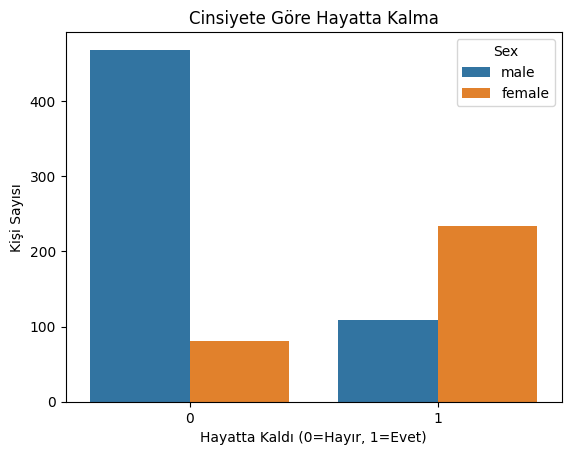

In [11]:
sns.countplot(data=df, x="Survived", hue="Sex")
plt.title("Cinsiyete Göre Hayatta Kalma")
plt.xlabel("Hayatta Kaldı (0=Hayır, 1=Evet)")
plt.ylabel("Kişi Sayısı")
plt.show()

## Bulgu 1: Cinsiyet ve Hayatta Kalma
Hayatta kalanların büyük çoğunluğu kadın, hayatta kalmayanların büyük çoğunluğu erkek.
Bu, gemide "önce kadınlar ve çocuklar" kuralının uygulandığını gösteriyor.

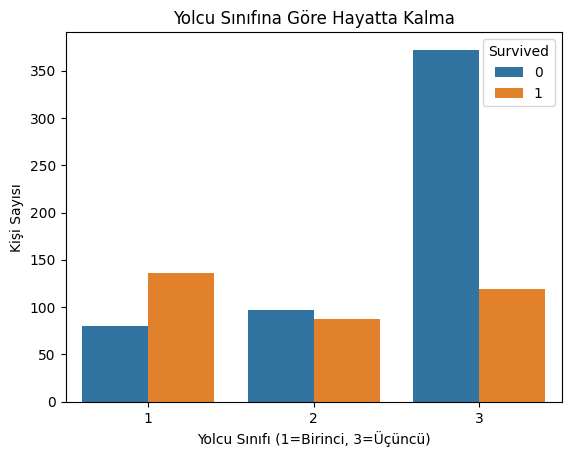

In [12]:
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Yolcu Sınıfına Göre Hayatta Kalma")
plt.xlabel("Yolcu Sınıfı (1=Birinci, 3=Üçüncü)")
plt.ylabel("Kişi Sayısı")
plt.show()

## Bulgu 2: Yolcu Sınıfı ve Hayatta Kalma
3. sınıf yolcuların ölüm oranı diğerlerine kıyasla çok daha yüksek.
1.sınıf yolcular en yüksek hayatta kalma oranına sahip.
Bu muhtemelen 1. sınıf yolcuların güverte erişimi ve kurtarma botlarına yakınlığıyla ilişkili.

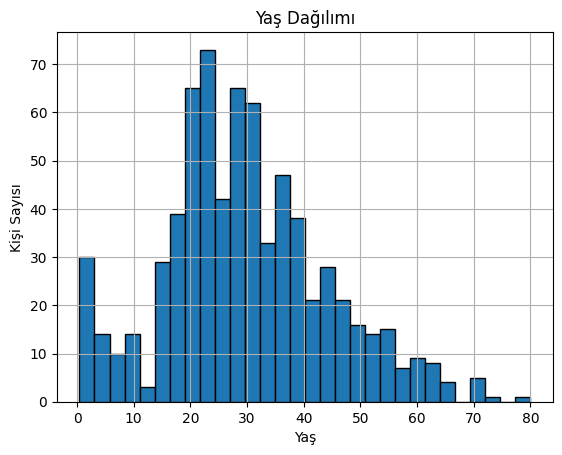

In [13]:
df["Age"].hist(bins=30, edgecolor="black")
plt.title("Yaş Dağılımı")
plt.xlabel("Yaş")
plt.ylabel("Kişi Sayısı")
plt.show()

## Bulgu 3: Yaş Dağılımı
Yolcular yeni doğan bebeklerden 80 yaşına kadar geniş bir aralıkta.
En yoğun grup 15-45 yaş arası, tepe nokta 22-24 civarında.
Genç yetişkinler gemideki en kalabalık grubu oluşturuyor.

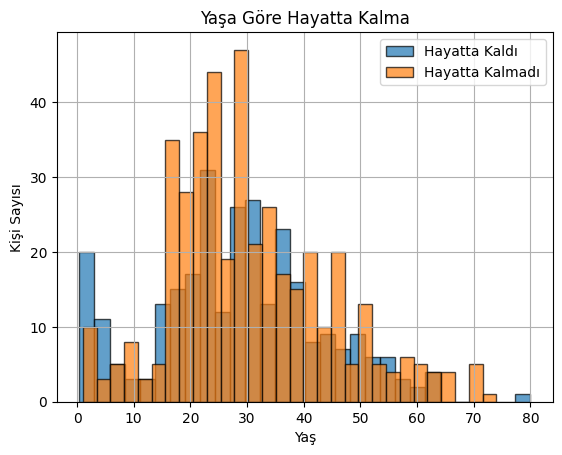

In [14]:
df[df["Survived"] == 1]["Age"].hist(bins=30, alpha=0.7, label="Hayatta Kaldı", edgecolor="black")
df[df["Survived"] == 0]["Age"].hist(bins=30, alpha=0.7, label="Hayatta Kalmadı", edgecolor="black")
plt.title("Yaşa Göre Hayatta Kalma")
plt.xlabel("Yaş")
plt.ylabel("Kişi Sayısı")
plt.legend()
plt.show()

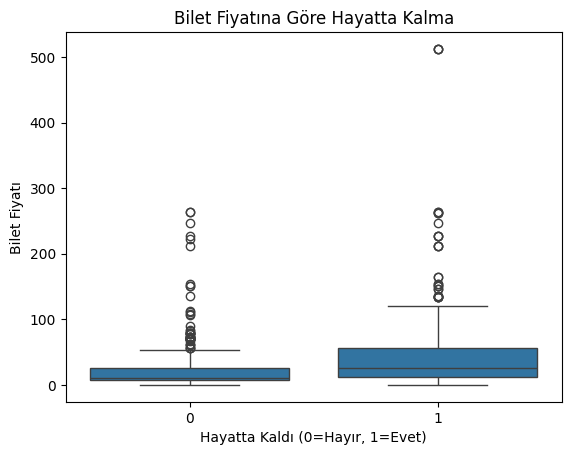

In [15]:
sns.boxplot(data=df, x="Survived", y="Fare")
plt.title("Bilet Fiyatına Göre Hayatta Kalma")
plt.xlabel("Hayatta Kaldı (0=Hayır, 1=Evet)")
plt.ylabel("Bilet Fiyatı")
plt.show()

## Bulgu 4: Bilet Fiyatı ve Hayatta Kalma
Hayatta kalanların medyan bilet fiyatı daha yüksek.
Pahalı bilet alan yolcular büyük ihtimalle 1. sınıftaydı
ve hayatta kalma oranları daha yüksekti.

In [16]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Embarked"].isnull().sum()

np.int64(0)

In [17]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Age"].isnull().sum()

np.int64(0)

In [18]:
df = df.drop(columns=["Cabin"])

In [19]:
df = df.drop(columns=["PassengerId", "Name", "Ticket"])

In [20]:
df.columns      

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [21]:
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

In [22]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


## Veri Ön İşleme Özeti
- Embarked: 2 eksik değer mod ile dolduruldu
- Age: 177 eksik değer medyan ile dolduruldu
- Cabin: %77 eksik olduğu için tamamen atıldı
- PassengerId, Name, Ticket: modele katkısı olmadığı için atıldı
- Sex ve Embarked: sayısal değerlere dönüştürüldü
- Geriye 8 anlamlı kolon kaldı, veri modele hazır

In [23]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

print(X.shape)
print(y.shape)

(891, 7)
(891,)


## Model Karşılaştırması

Üç farklı model aynı veri ve aynı train/test split ile değerlendirildi.

========== MODEL KARŞILAŞTIRMA ==========
              Model  Test Accuracy  CV Ortalama
Logistic Regression         0.7977       0.8100
      Decision Tree         0.7989       0.8371
      Random Forest         0.7989       0.8261


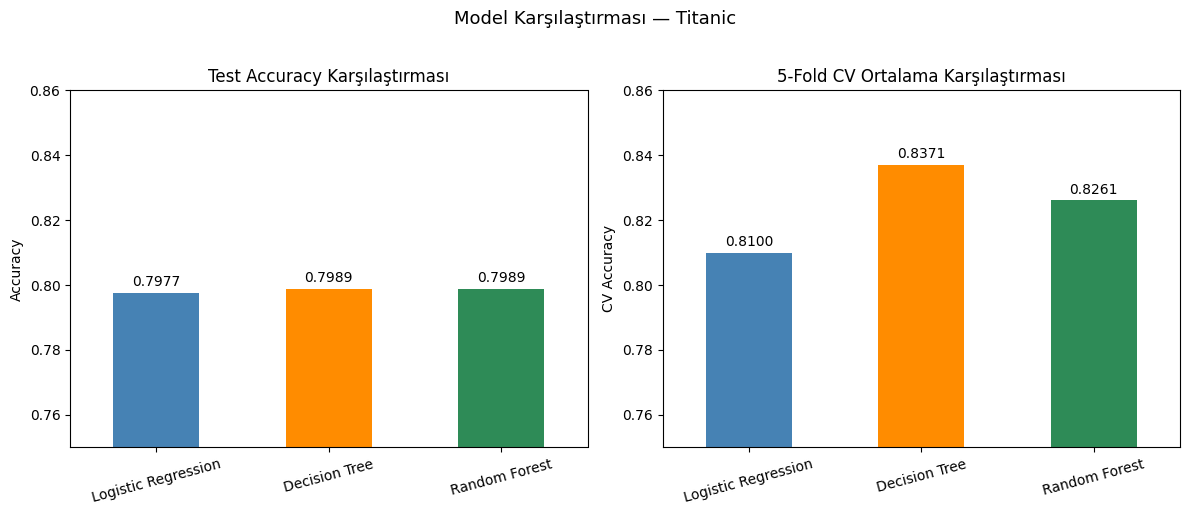

In [24]:
results = pd.DataFrame({
    "Model"        : ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Test Accuracy": [0.7977, 0.7989, 0.7989],
    "CV Ortalama"  : [0.8100, 0.8371, 0.8261]
})

print("========== MODEL KARŞILAŞTIRMA ==========")
print(results.to_string(index=False))
print("=========================================")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["steelblue", "darkorange", "seagreen"]

results.plot(
    kind="bar", x="Model", y="Test Accuracy",
    ax=axes[0], color=colors, legend=False, ylim=(0.75, 0.86)
)
axes[0].set_title("Test Accuracy Karşılaştırması")
axes[0].set_xlabel("")
axes[0].set_ylabel("Accuracy")
axes[0].tick_params(axis="x", rotation=15)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{bar.get_height():.4f}",
        ha="center", va="bottom", fontsize=10
    )

results.plot(
    kind="bar", x="Model", y="CV Ortalama",
    ax=axes[1], color=colors, legend=False, ylim=(0.75, 0.86)
)
axes[1].set_title("5-Fold CV Ortalama Karşılaştırması")
axes[1].set_xlabel("")
axes[1].set_ylabel("CV Accuracy")
axes[1].tick_params(axis="x", rotation=15)
for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{bar.get_height():.4f}",
        ha="center", va="bottom", fontsize=10
    )

plt.suptitle("Model Karşılaştırması — Titanic", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
